<a href="https://colab.research.google.com/github/Srinivaas-only/Banking-Campaign-Data-Analysis/blob/main/Banking_System_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [87]:
#Importing necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [88]:
#Import csv file (read it)
df = pd.read_csv('/content/banking_data.csv')

In [89]:
#Lets see if the file is correct by checking row and column
df.shape

(45216, 19)

In [90]:
df.head(-1)

,age,job,marital,marital_status,education,default,balance,housing,loan,contact,day,month,day_month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,married,tertiary,no,2143,yes,no,unknown,5,may,5-May,261,1,-1,0,unknown,no
1,44,technician,single,single,secondary,no,29,yes,no,unknown,5,may,5-May,151,1,-1,0,unknown,no
2,33,entrepreneur,married,married,secondary,no,2,yes,yes,unknown,5,may,5-May,76,1,-1,0,unknown,no
3,47,blue-collar,married,married,unknown,no,1506,yes,no,unknown,5,may,5-May,92,1,-1,0,unknown,no
4,33,unknown,single,single,unknown,no,1,no,no,unknown,5,may,5-May,198,1,-1,0,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45210,37,entrepreneur,married,married,secondary,no,2971,no,no,cellular,17,nov,17-Nov,361,2,188,11,other,no
45211,29,management,single,single,tertiary,no,765,no,no,cellular,16,nov,16-Nov,238,1,-1,0,unknown,yes
45212,68,retired,married,married,secondary,no,1146,no,no,cellular,16,nov,16-Nov,212,1,187,6,success,yes
45213,53,management,married,married,tertiary,no,583,no,no,cellular,17,nov,17-Nov,226,1,184,4,success,yes


In [91]:
df.isnull().sum()

,0
age,0
job,0
marital,3
marital_status,3
education,3
default,0
balance,0
housing,0
loan,0
contact,0


In [92]:
df['marital_status']=df['marital_status'].fillna('unknown')
df['marital']= df['marital'].fillna('unknown')
df['education']=df['education'].fillna('unknown')
df.isnull().sum()

,0
age,0
job,0
marital,0
marital_status,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0


In [93]:
df.dtypes

,0
age,int64
job,object
marital,object
marital_status,object
education,object
default,object
balance,int64
housing,object
loan,object
contact,object


In [94]:
df = df.drop(columns=['marital_status'])

In [95]:
df.shape

(45216, 18)

--- Q1: Age Stats ---
Youngest client: 18
Oldest client: 95
Average (mean) age: 40.9


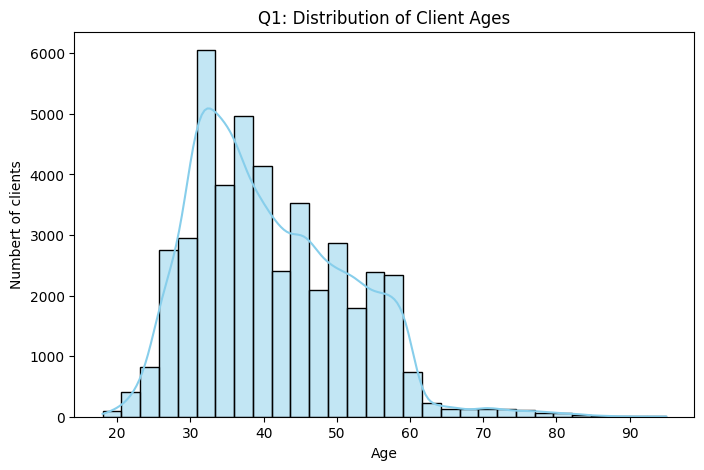

In [96]:
#Q1
print("--- Q1: Age Stats ---")
print("Youngest client:", df['age'].min())
print("Oldest client:", df['age'].max())
print("Average (mean) age:", round(df['age'].mean(),1))

plt.figure(figsize=(8,5))
sns.histplot(df['age'],bins=30,  kde=True,color='skyblue')
plt.title('Q1: Distribution of Client Ages')
plt.xlabel('Age')
plt.ylabel('Numbert of clients')
plt.show()

--- Q2: Job Type Percentages ---
job
blue-collar      21.5
management       20.9
technician       16.8
admin.           11.4
services          9.2
retired           5.0
self-employed     3.5
entrepreneur      3.3
unemployed        2.9
housemaid         2.7
student           2.1
unknown           0.6
Name: proportion, dtype: float64


/tmp/ipykernel_5196/4264388492.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df , y='job', order=df['job'].value_counts().index, palette = 'viridis')


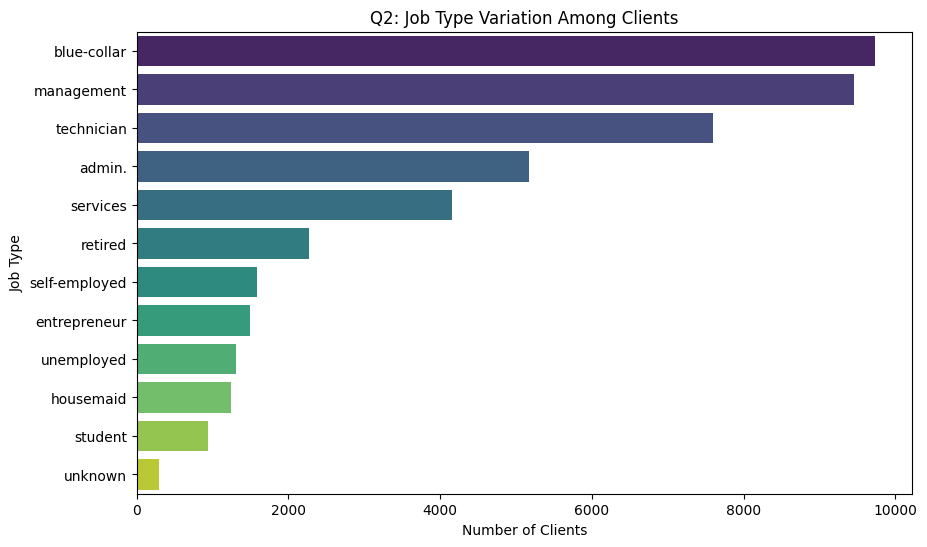

In [97]:
# 1. Calculate and print the exact percentages for each job
print("--- Q2: Job Type Percentages ---")
job_percentages = df['job'].value_counts(normalize=True)*100
print(round(job_percentages,1))

#2 plot the bar chart
plt.figure(figsize=(10,6))
sns.countplot(data=df , y='job', order=df['job'].value_counts().index, palette = 'viridis')
plt.title('Q2: Job Type Variation Among Clients')
plt.xlabel('Number of Clients')
plt.ylabel('Job Type')
plt.show()

---Marital Status Percentage---
marital
married     60.2
single      28.3
divorced    11.5
unknown      0.0
Name: proportion, dtype: float64


/tmp/ipykernel_5196/2069158465.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df,x='marital', order=df['marital'].value_counts().index, palette='pastel')


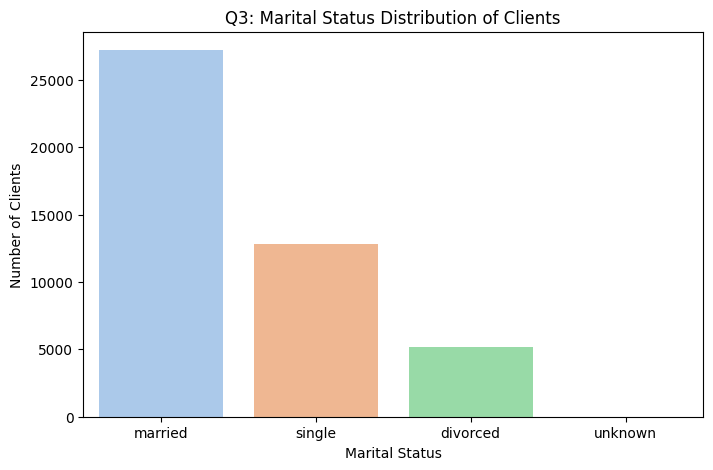

In [98]:
#Q3 - 'Q3: Marital Status Distribution of Clients'
#Print marital_percentage
print("---Marital Status Percentage---")
marital_percentages = df['marital'].value_counts(normalize=True)*100
print(round(marital_percentages,1))

#2.Plot the Bar Chart
plt.figure(figsize=(8,5))
sns.countplot(data=df,x='marital', order=df['marital'].value_counts().index, palette='pastel')
plt.title('Q3: Marital Status Distribution of Clients')
plt.xlabel('Marital Status')
plt.ylabel('Number of Clients')
plt.show()

--- Q4: Education Level Percentages ---
education
secondary    51.3
tertiary     29.4
primary      15.2
unknown       4.1
Name: proportion, dtype: float64


/tmp/ipykernel_5196/2892837730.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df , x='education', order=df['education'].value_counts().index , palette='Set2' )


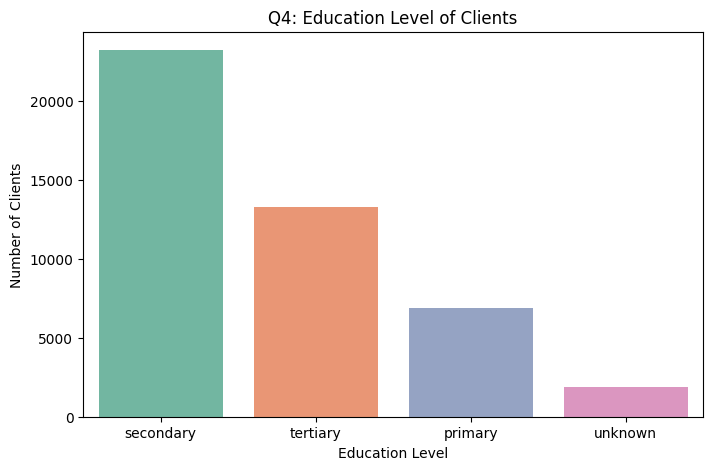

In [99]:
#Q4: Education Level of Clients
#Find percentage of education level of clients
print("--- Q4: Education Level Percentages ---")
education_percentage = df['education'].value_counts(normalize = True) * 100
print(round(education_percentage,1))

# 2. Plot the Bar Chart
plt.figure(figsize=(8,5))
sns.countplot(data=df , x='education', order=df['education'].value_counts().index , palette='Set2' )
plt.title('Q4: Education Level of Clients')
plt.xlabel('Education Level')
plt.ylabel('Number of Clients')
plt.show()

--- Q5: Credit Default Proportions ---
default
no     98.2
yes     1.8
Name: proportion, dtype: float64


/tmp/ipykernel_5196/2239255058.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='default',order = df['default'].value_counts().index,palette = 'Set1' )


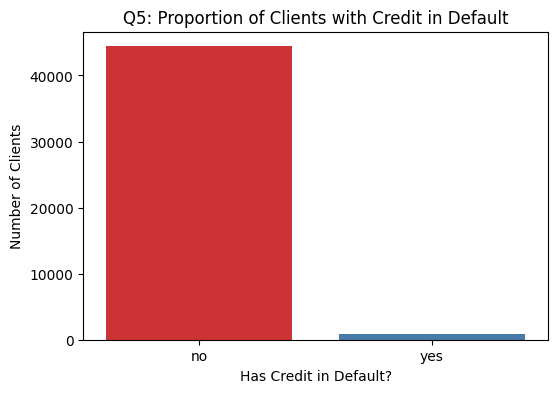

In [100]:
#Q5: Proportion of Clients with Credit in Default
print("--- Q5: Credit Default Proportions ---")
default_percentages = df['default'].value_counts(normalize=True)*100
print(round(default_percentages,1))

# 2. Plot the Bar Chart
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='default',order = df['default'].value_counts().index,palette = 'Set1' )
plt.title('Q5: Proportion of Clients with Credit in Default')
plt.xlabel('Has Credit in Default?')
plt.ylabel('Number of Clients')
plt.show()

--- Q6: Average Yearly Balance Stats ---
Lowest Balance (In Debt): -8019
Highest Balance: 102127
Average(Mean) 1362.28
Median (True Middle): 448.5


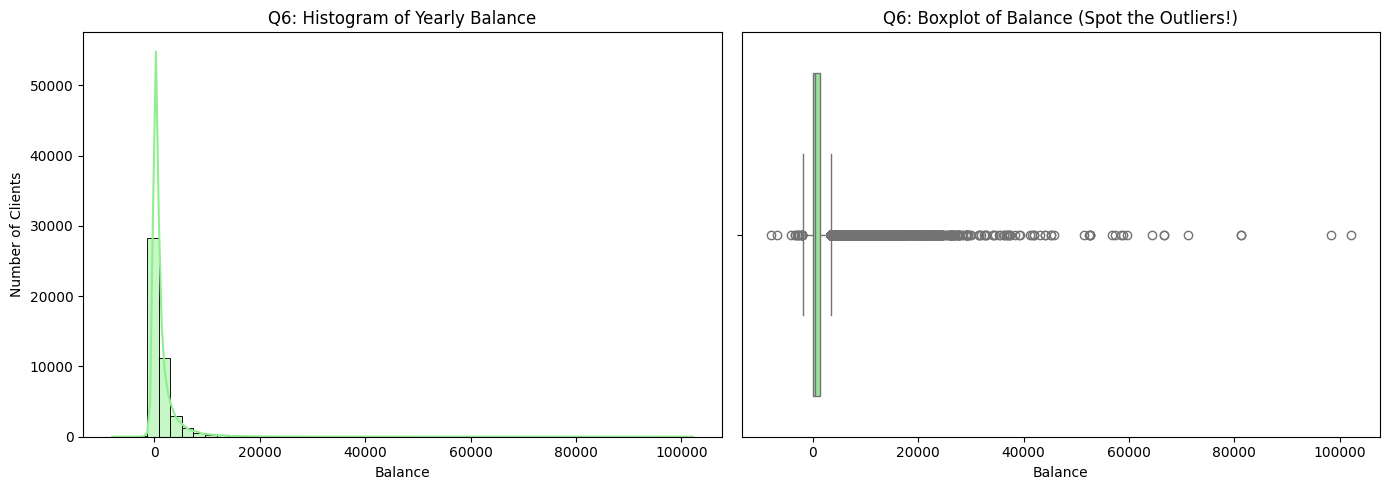

In [101]:
print("--- Q6: Average Yearly Balance Stats ---")
print("Lowest Balance (In Debt):", df['balance'].min())
print("Highest Balance:", df['balance'].max())
print("Average(Mean)", round(df['balance'].mean(),2))
print("Median (True Middle):", df['balance'].median())

# 2. Plot the Histogram AND Boxplot side-by-side
fig,axes = plt.subplots(1,2,figsize=(14,5))

#Histogram
sns.histplot(df['balance'], bins=50, kde=True,ax=axes[0], color='lightgreen')
axes[0].set_title('Q6: Histogram of Yearly Balance')
axes[0].set_xlabel('Balance')
axes[0].set_ylabel('Number of Clients')

#Boxplot
sns.boxplot(x=df['balance'], ax=axes[1], color='lightgreen')
axes[1].set_title('Q6: Boxplot of Balance (Spot the Outliers!)')
axes[1].set_xlabel('Balance')

plt.tight_layout()
plt.show()

--- Q7: Housing Loans ---
housing
yes    55.6
no     44.4
Name: proportion, dtype: float64

--- Q8: Personal Loans ---
loan
no     84.0
yes    16.0
Name: proportion, dtype: float64


/tmp/ipykernel_5196/1360044554.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data = df, x='housing', order=df['housing'].value_counts().index, ax=axes[0], palette='Blues')
/tmp/ipykernel_5196/1360044554.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data = df, x= 'loan', order=df['loan'].value_counts().index, ax=axes[1], palette="Oranges")


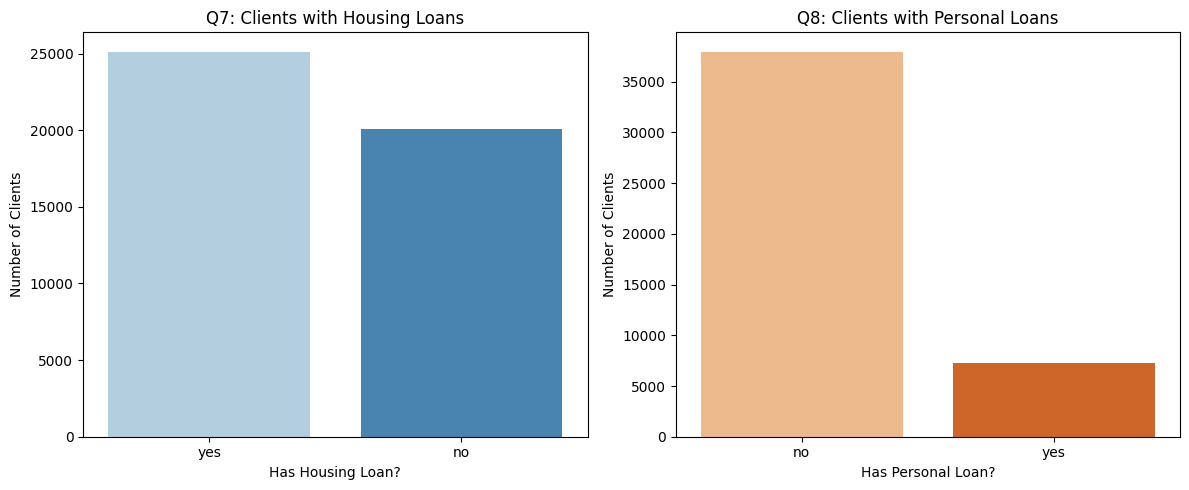

In [102]:
# 1. Print the exact percentages for Housing Loans
print("--- Q7: Housing Loans ---")
housing_percents = df['housing'].value_counts(normalize=True)*100
print(round(housing_percents,1))
# 2. Print the exact percentages for Personal Loans
print("\n--- Q8: Personal Loans ---")
loan_percentages = df['loan'].value_counts(normalize=True) * 100
print(loan_percentages.round(1))

fig , axes = plt.subplots(1,2, figsize=(12,5))

#Q7 Chart
sns.countplot(data = df, x='housing', order=df['housing'].value_counts().index, ax=axes[0], palette='Blues')
axes[0].set_title('Q7: Clients with Housing Loans')
axes[0].set_xlabel('Has Housing Loan?')
axes[0].set_ylabel('Number of Clients')

# Q8 Chart
sns.countplot(data = df, x= 'loan', order=df['loan'].value_counts().index, ax=axes[1], palette="Oranges")
axes[1].set_title('Q8: Clients with Personal Loans')
axes[1].set_xlabel('Has Personal Loan?')
axes[1].set_ylabel('Number of Clients')

plt.tight_layout()
plt.show()

--- Q9: Communication Types ---
contact
cellular     64.8
unknown      28.8
telephone     6.4
Name: proportion, dtype: float64


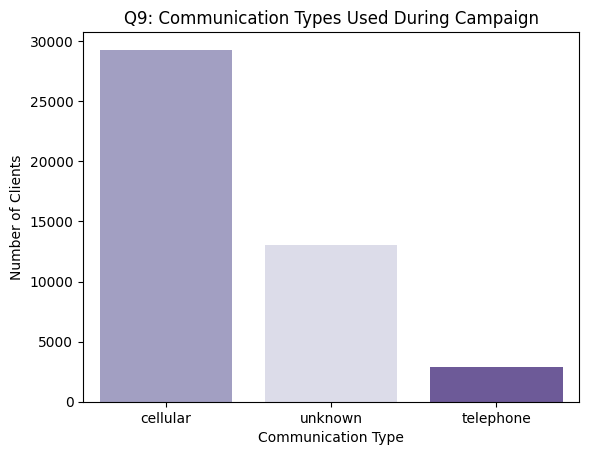

In [103]:
#Q9: Communication Types Used During Campaign

print("--- Q9: Communication Types ---")
comm_percentages = df['contact'].value_counts(normalize=True)*100
print(round(comm_percentages,1))

#Plot bar chart
sns.countplot(data=df, x='contact', hue='contact', order=df['contact'].value_counts().index, palette='Purples', legend=False)
plt.title('Q9: Communication Types Used During Campaign')
plt.xlabel('Communication Type')
plt.ylabel('Number of Clients')
plt.show()

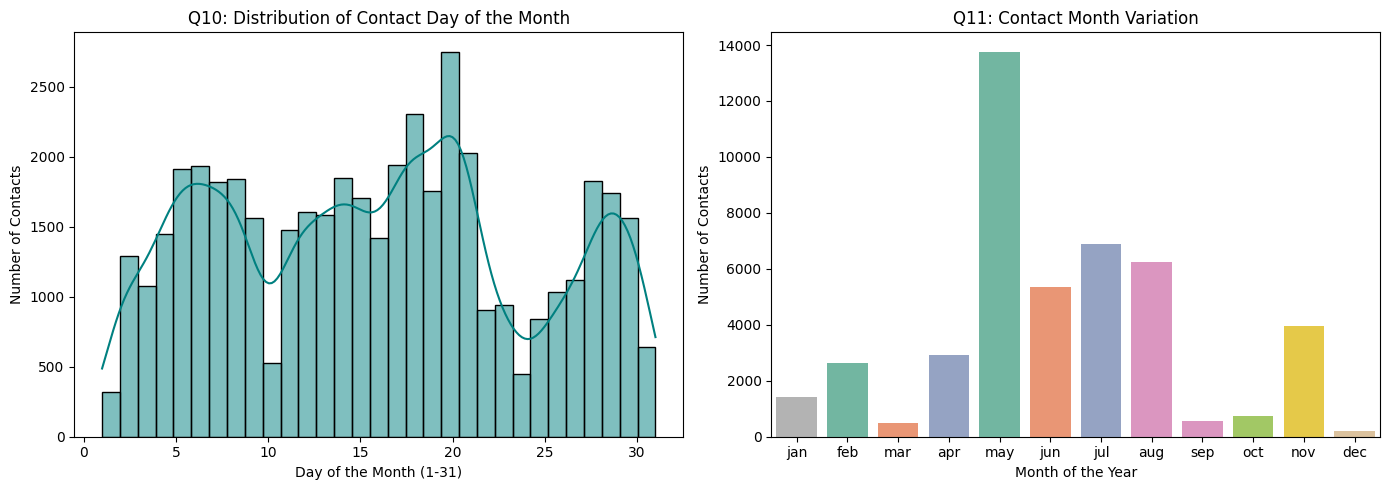

In [104]:
#Q10 Chart: Histogram for the Day (Numerical)
fig,axes = plt.subplots(1,2,figsize=(14,5))
sns.histplot(data=df ,x='day', bins = 31,kde=True, ax=axes[0],color='teal')
axes[0].set_title('Q10: Distribution of Contact Day of the Month')
axes[0].set_xlabel('Day of the Month (1-31)')
axes[0].set_ylabel('Number of Contacts')

# Q11 Chart: Bar Chart for the Month (Categorical)
month_order = ['jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']
sns.countplot(data=df, x='month', hue='month', order=month_order,ax=axes[1],palette='Set2', legend=False)
axes[1].set_title('Q11: Contact Month Variation')
axes[1].set_xlabel('Month of the Year')
axes[1].set_ylabel('Number of Contacts')

plt.tight_layout()
plt.show()


In [105]:
df['pdays'].head(-1)

,pdays
0,-1
1,-1
2,-1
3,-1
4,-1
...,...
45210,188
45211,-1
45212,187
45213,184


--- Q12: Call Duration Stats ---
Shortest Call: 0 seconds
Longest Call: 4918 seconds
Average (Mean) Call: 258.2 seconds
Median Call: 180.0 seconds


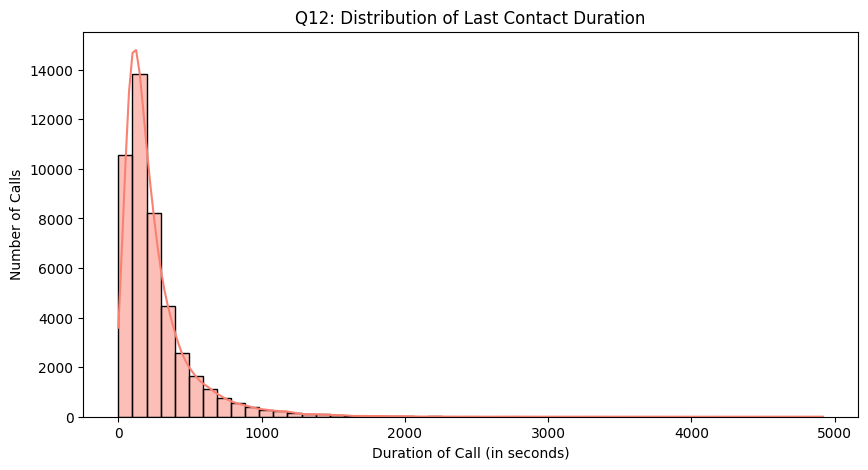


The distribution of the last contact duration is highly right-skewed. The vast majority of phone calls are relatively short, with the median call lasting only 180 seconds (3 minutes). However, there is a long tail indicating a small number of extremely long conversations, with the maximum call duration reaching nearly 4,918 seconds (over 1 hour and 20 minutes!).


In [106]:
#Q12: Distribution of Last Contact Duration
# 1. Print the exact stats
print("--- Q12: Call Duration Stats ---")
print("Shortest Call:",df['duration'].min(),"seconds")
print("Longest Call:", df['duration'].max(),"seconds")
print("Average (Mean) Call:", round(df['duration'].mean(),1),"seconds")
print("Median Call:", df['duration'].median(), "seconds")

#Plot The Histogram
plt.figure(figsize=(10,5))
sns.histplot(data=df,x='duration',bins=50,kde=True,color='salmon')
plt.title('Q12: Distribution of Last Contact Duration')
plt.xlabel('Duration of Call (in seconds)')
plt.ylabel('Number of Calls')
plt.show()
print("\nThe distribution of the last contact duration is highly right-skewed. The vast majority of phone calls are relatively short, with the median call lasting only 180 seconds (3 minutes). However, there is a long tail indicating a small number of extremely long conversations, with the maximum call duration reaching nearly 4,918 seconds (over 1 hour and 20 minutes!).")